# Obstacle Pipeline — Step-by-Step Visualization

This notebook runs and visualizes each stage of the obstacle-detection pipeline on a single image, so we can inspect intermediate results while debugging:

1. **Imports & config** — libraries and base paths.
2. **Load image** — read a test image and show it.
3. **SAM2** — "segment everything" masks.
4. **Depth-Anything-3** — per-pixel depth map.
5. **Side-by-side** — original vs. SAM2 vs. depth for quick comparison.

In [9]:
# Only for imports
%matplotlib inline
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Imports & configuration

Standard imaging libs (`cv2`, `numpy`, `matplotlib`) plus `BASE_DIR`, the project root on the Azure server. `%matplotlib inline` ensures plots render in the notebook. The `os.listdir(...)` cell just lists available test images to pick from.

In [10]:
# Project root on the Azure server (all model/image paths hang off this)
BASE_DIR = "/mnt/aitraining/krishna/2026/obstacle_pipeline"

In [11]:
# List available obstacle test images to choose from
os.listdir("./test_images/obstacle")

['.ipynb_checkpoints',
 '50e23aed-3e95-4888-9ee4-c4acf18ede44.png',
 '614bafa7-a4ca-4abd-ba7e-9ba3b1c72166.png',
 '81a0d0e1-c5b4-4c86-88ce-4ed478b12ee6.png',
 '81c8cfe3-dbf1-4015-bb0d-5fa5522298f9.png',
 '9364f98d-5cc3-4620-9142-f147cfd3b96b.png',
 '9b8f8464-4921-4ba7-8778-b96fcd174517.png',
 '9f15afc2-4441-4040-9722-7c87a2e4fcbc.png',
 'a8d7057a-5c4e-4f10-8c4e-f83b88fad75f.png']

## 2. Load the input image

Read one test image with OpenCV (BGR) and convert to RGB for correct colors in matplotlib. `image_rgb` is reused by every later step. Edit `image_path` to test a different image.

Loaded: /mnt/aitraining/krishna/2026/obstacle_pipeline/test_images/obstacle/81a0d0e1-c5b4-4c86-88ce-4ed478b12ee6.png
Shape: (1080, 607, 3)


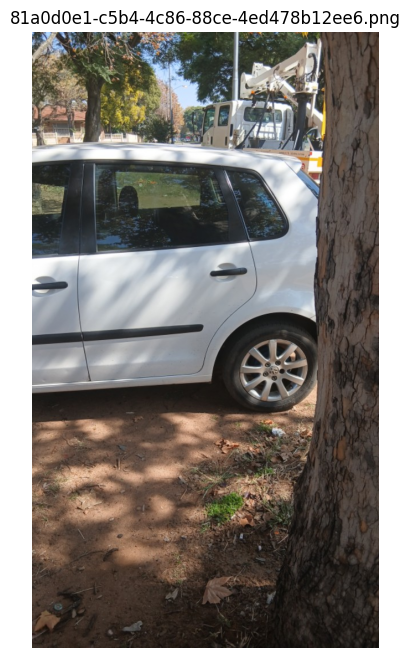

In [12]:
# Load an image and visualize it
image_path = os.path.join(BASE_DIR, "test_images", "obstacle", "81a0d0e1-c5b4-4c86-88ce-4ed478b12ee6.png")

# OpenCV loads as BGR; convert to RGB for display
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Loaded: {image_path}")
print(f"Shape: {image_rgb.shape}")

plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.title(os.path.basename(image_path))
plt.axis("off")
plt.show()

## 3. SAM2 — segment everything

Run SAM2 (`sam2.1_b.pt`) in automatic "segment everything" mode to get all candidate object masks. `result.masks.data` is `(N, H, W)`; we overlay each mask in a random color. These masks are later filtered against the car and depth to decide which are obstacles. Produces `masks` and `overlay`.

SAM2 produced 9 masks


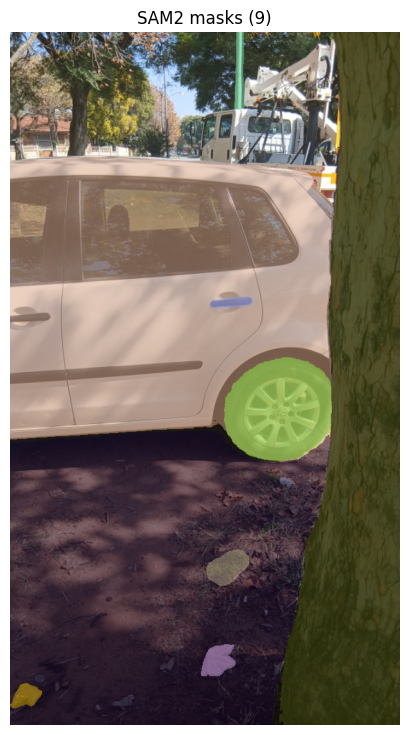

In [13]:
# Run SAM2 ("segment everything") and visualize the masks
from ultralytics import SAM

sam = SAM("/mnt/aitraining/krishna/2026/obstacle_pipeline/sam2.1_b.pt")
result = sam(image_path, device="cuda", verbose=False)[0]

# masks.data is (N, H, W) at the model's resolution
masks = result.masks.data.cpu().numpy().astype(bool)
print(f"SAM2 produced {len(masks)} masks")

# Build a colored overlay: each mask gets a random color
overlay = image_rgb.copy()
rng = np.random.default_rng(0)
for m in masks:
    # mask may differ in size from the original image -> resize to match
    m_resized = cv2.resize(m.astype(np.uint8), (image_rgb.shape[1], image_rgb.shape[0]),
                           interpolation=cv2.INTER_NEAREST).astype(bool)
    color = rng.integers(0, 255, size=3)
    overlay[m_resized] = (0.5 * overlay[m_resized] + 0.5 * color).astype(np.uint8)

plt.figure(figsize=(12, 9))
plt.imshow(overlay)
plt.title(f"SAM2 masks ({len(masks)})")
plt.axis("off")
plt.show()

## 3b. Vehicle detection

Run the vehicle model (YOLOv11m-seg) via `VehicleModelHandler` to detect/segment the car. The pipeline uses this only to pick WHICH SAM blob is the car (best overlap with the vehicle region). `prediction.draw(...)` paints the detected boxes/masks. Produces `veh_pred` and `veh_overlay`.

[INFO] Initializing Vehicle Model Handler on device: cuda
[INFO] Using weights: /mnt/aitraining/krishna/2026/obstacle_pipeline/vehicle_model/vehicle_detection_yolov11m_segm_v3_1.pt
Vehicle model detected 1 instance(s)


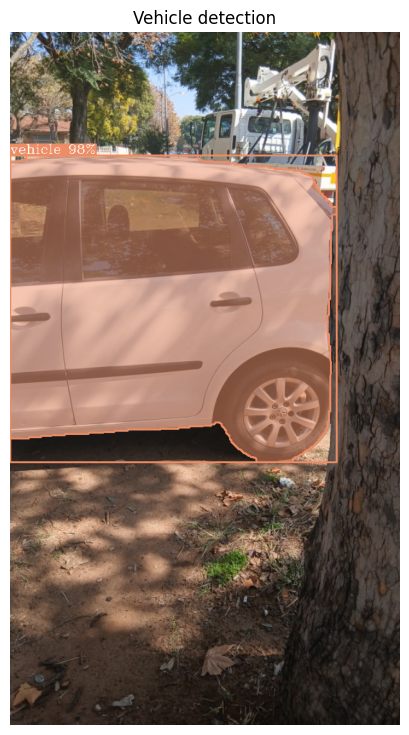

In [14]:
# Run the vehicle model and visualize the detection
from obstacle_detection.handlers import VehicleModelHandler

veh = VehicleModelHandler()
veh_pred = veh.infer(image_path)
print(f"Vehicle model detected {len(veh_pred.instances)} instance(s)")

# draw() paints the predicted boxes/masks onto a copy of the (RGB) image,
# same as the pipeline's veh panel (detector._viz_panels).
veh_overlay = veh_pred.draw(image_rgb.copy())

plt.figure(figsize=(12, 9))
plt.imshow(veh_overlay)
plt.title("Vehicle detection")
plt.axis("off")
plt.show()

## 4. Depth-Anything-3 — depth map

Run DA3 via the project's `DepthAnything3Handler`. `prediction.depth[0]` is the raw **metric** depth `(H, W)` where **smaller = closer** to the camera; `visualize_depth` produces the colored map shown here. Produces `depth_map` (raw) and `depth_colored` (for display).

[INFO] Initializing Depth Anything V3 on device: cuda


06/05/2026 08:40:20 - INFO - httpx -   HTTP Request: HEAD https://huggingface.co/depth-anything/DA3-LARGE-1.1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
06/05/2026 08:40:20 - INFO - httpx -   HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/depth-anything/DA3-LARGE-1.1/0e109ae307c5982f319a67cf6f9f99ccdc0ec97c/config.json "HTTP/1.1 200 OK"


[INFO ] using MLP layer as FFN


06/05/2026 08:40:24 - INFO - httpx -   HTTP Request: HEAD https://huggingface.co/depth-anything/DA3-LARGE-1.1/resolve/main/model.safetensors "HTTP/1.1 302 Found"


[INFO ] Processed Images Done taking 0.09044218063354492 seconds. Shape:  torch.Size([1, 3, 504, 280])
[INFO ] Model Forward Pass Done. Time: 1.1689043045043945 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0005173683166503906 seconds
Depth map shape: (504, 280), range: 0.34..6.92


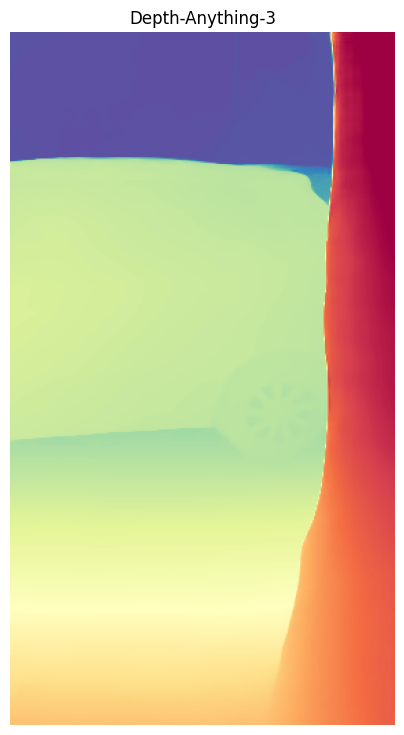

In [15]:
# Run Depth-Anything-3 and visualize the depth map
from obstacle_detection.handlers import DepthAnything3Handler
from depth_anything_3.utils.visualize import visualize_depth

da3 = DepthAnything3Handler()
prediction = da3.infer(image_path)

# Raw metric depth (H, W); smaller value = closer to camera
depth_map = prediction.depth[0]
print(f"Depth map shape: {depth_map.shape}, range: {depth_map.min():.2f}..{depth_map.max():.2f}")

# Colored visualization (same helper the handler uses to save)
depth_colored = visualize_depth(depth_map)

plt.figure(figsize=(12, 9))
plt.imshow(depth_colored)
plt.title("Depth-Anything-3")
plt.axis("off")
plt.show()

## 4b. Identify the car mask

Pick the single SAM mask that represents the car by comparing every SAM mask against the vehicle region (highest IoU). This mirrors the pipeline: `_vehicle_region` turns the vehicle prediction into a binary silhouette (segmentation mask preferred, bbox fallback), then `identify_car_region` chooses + clips the SAM blob. Needs `depth_map` (above) and `veh_pred`. Produces `car` and `car_overlay`.

Car = SAM mask 0 (seed: vehicle, IoU 0.985, avg depth 0.984)


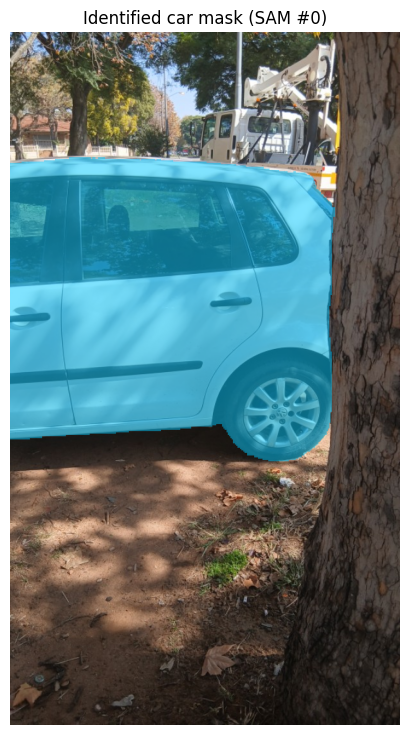

In [17]:
# Identify the car SAM mask by comparing SAM masks with the vehicle region
from obstacle_detection import identify_car_region
from obstacle_detection.detector import _vehicle_region

img_h, img_w = depth_map.shape

# SAM masks must be at depth-map resolution for the overlap comparison.
sam_masks = masks
if sam_masks.shape[1:] != (img_h, img_w):
    sam_masks = np.array([cv2.resize(m.astype(np.uint8), (img_w, img_h),
                                     interpolation=cv2.INTER_NEAREST) for m in masks])

# Binary vehicle silhouette from the vehicle prediction (mask preferred, bbox fallback).
v_region_bin = _vehicle_region(veh_pred, img_h, img_w)

car = identify_car_region(sam_masks, depth_map, v_region_bin)
if car is None:
    print("[WARN] No car identified.")
else:
    print(f"Car = SAM mask {car['car_idx']} (seed: {car['seed_src']}, "
          f"IoU {car['best_iou']:.3f}, avg depth {car['car_depth']:.3f})")

    # Paint the identified (cleaned) car mask in cyan over the original.
    car_mask = cv2.resize(car["car_mask_bin"].astype(np.uint8),
                          (image_rgb.shape[1], image_rgb.shape[0]),
                          interpolation=cv2.INTER_NEAREST).astype(bool)
    car_overlay = image_rgb.copy()
    car_overlay[car_mask] = (0.5 * car_overlay[car_mask]
                             + 0.5 * np.array([0, 200, 255])).astype(np.uint8)

    plt.figure(figsize=(12, 9))
    plt.imshow(car_overlay)
    plt.title(f"Identified car mask (SAM #{car['car_idx']})")
    plt.axis("off")
    plt.show()

## 5. Side-by-side comparison

Plot the original image, the SAM2 mask overlay, and the DA3 depth map together in one row for a quick visual sanity check across stages.

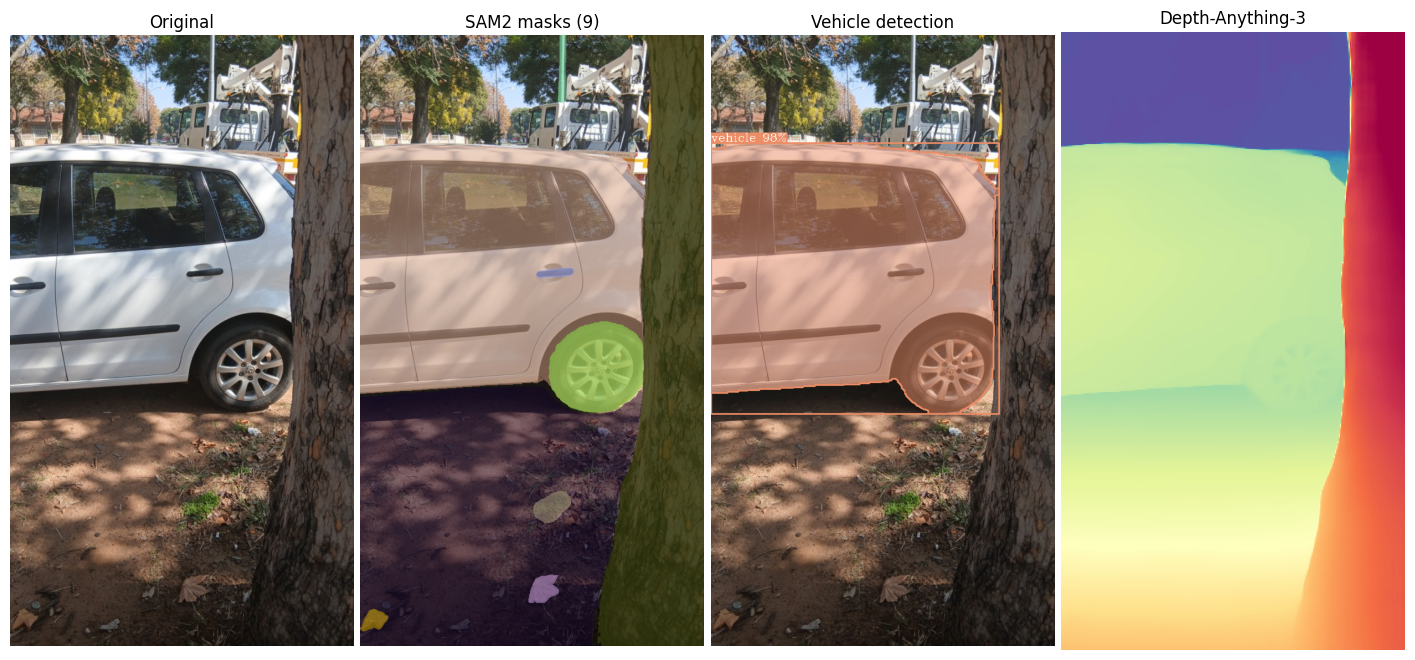

In [16]:
# Side-by-side: original | SAM2 masks | vehicle detection | DA3 depth
fig, axes = plt.subplots(1, 4, figsize=(18, 9), gridspec_kw={"wspace": 0.02})

axes[0].imshow(image_rgb)
axes[0].set_title("Original")

axes[1].imshow(overlay)
axes[1].set_title(f"SAM2 masks ({len(masks)})")

axes[2].imshow(veh_overlay)
axes[2].set_title("Vehicle detection")

axes[3].imshow(depth_colored)
axes[3].set_title("Depth-Anything-3")

for ax in axes:
    ax.axis("off")

plt.show()

## 6. Filter out background masks

Drop every SAM mask that is NOT foreground — i.e. not closer to the camera than the car. Using the same rule as `find_obstacles`: a mask is foreground when its mean depth `< car_depth * (1 - depth_margin)` (metric depth, smaller = closer). The car mask itself is excluded. Side-by-side: all SAM masks vs. the foreground-only masks that survive.

Foreground masks: 5 / 9 (car_depth 0.984, threshold 0.935)


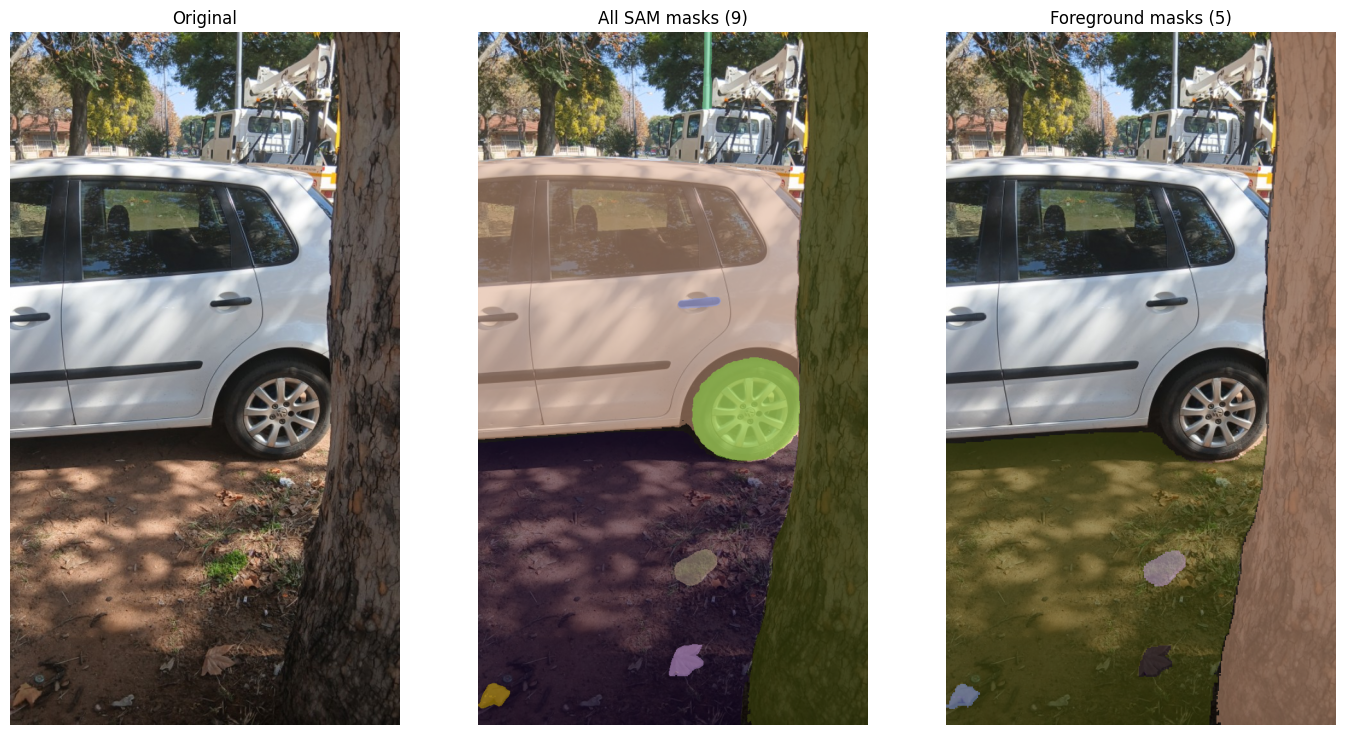

In [18]:
# Keep only FOREGROUND masks (closer than the car), then compare side by side
from obstacle_detection import ObstacleConfig

cfg = ObstacleConfig()
car_depth = car["car_depth"]
car_idx = car["car_idx"]
foreground_thresh = car_depth * (1.0 - cfg.depth_margin)   # must be CLOSER than this

# sam_masks are already at depth-map resolution (from the car cell above).
foreground_idx = []
for i, s_mask in enumerate(sam_masks):
    if i == car_idx:
        continue
    s_bin = s_mask > 0.5
    if s_bin.sum() == 0:
        continue
    mask_depth = float(np.mean(depth_map[s_bin]))
    if mask_depth < foreground_thresh:
        foreground_idx.append(i)

print(f"Foreground masks: {len(foreground_idx)} / {len(sam_masks)} "
      f"(car_depth {car_depth:.3f}, threshold {foreground_thresh:.3f})")

# Build a colored overlay for a given set of mask indices.
def _overlay_for(indices):
    out = image_rgb.copy()
    rng = np.random.default_rng(0)
    for i in indices:
        m = cv2.resize(sam_masks[i].astype(np.uint8),
                       (image_rgb.shape[1], image_rgb.shape[0]),
                       interpolation=cv2.INTER_NEAREST).astype(bool)
        color = rng.integers(0, 255, size=3)
        out[m] = (0.5 * out[m] + 0.5 * color).astype(np.uint8)
    return out

foreground_overlay = _overlay_for(foreground_idx)

fig, axes = plt.subplots(1, 3, figsize=(18, 9), gridspec_kw={"wspace": 0.02})
axes[0].imshow(image_rgb); axes[0].set_title("Original")
axes[1].imshow(overlay); axes[1].set_title(f"All SAM masks ({len(masks)})")
axes[2].imshow(foreground_overlay)
axes[2].set_title(f"Foreground masks ({len(foreground_idx)})")
for ax in axes:
    ax.axis("off")
plt.show()

## 7. Obstacle identification (inline)

The obstacle decision spelled out here in the notebook instead of calling `find_obstacles`, so each filter can be inspected / tweaked. A SAM mask is an obstacle iff it is: big enough, NOT a car part (not inside the vehicle silhouette), FOREGROUND (closer than the car), NOT the receding ground plane, and **touches the car mask** (any pixel overlapping or adjacent to it — the fractional `min_car_overlap` threshold is replaced by a simple touch test). Produces `obstacle_idx` / `obstacle_exist`, consumed by the final plot cell.

In [22]:
# Inline obstacle identification (any mask TOUCHING the car -> obstacle)
from obstacle_detection import ObstacleConfig

cfg = ObstacleConfig()
car_mask_bin = car["car_mask_bin"]
vehicle_mask_bin = car.get("vehicle_mask_bin")
car_idx = car["car_idx"]
car_depth = car["car_depth"]

# A mask inside the vehicle silhouette is a car PART; fall back to the SAM car
# mask when there is no vehicle mask.
car_part_ref = vehicle_mask_bin if vehicle_mask_bin is not None else car_mask_bin

img_h, img_w = depth_map.shape
img_area = img_h * img_w
foreground_thresh = car_depth * (1.0 - cfg.depth_margin)   # must be CLOSER than this

# Dilate the car mask by 1px so masks that are adjacent (touching) but not
# strictly overlapping still count as touching the car.
car_touch_ref = cv2.dilate(car_mask_bin.astype(np.uint8),
                           np.ones((3, 3), np.uint8), iterations=1).astype(bool)

obstacle_idx = []
for i, s_mask in enumerate(sam_masks):
    if i == car_idx:
        continue

    s_bin = s_mask > 0.5
    mask_area = int(s_bin.sum())
    if mask_area == 0:
        continue

    # --- AREA: drop specks --------------------------------------------------
    if mask_area < img_area * cfg.min_area_ratio:
        print(f"[skip] Mask {i}: too small (area_ratio {mask_area / img_area:.4f})")
        continue

    # --- CAR PART: mask sits inside the vehicle silhouette ------------------
    if car_part_ref is not None:
        part_containment = np.logical_and(s_bin, car_part_ref).sum() / mask_area
        if part_containment > cfg.car_part_containment:
            print(f"[skip] Mask {i}: car part (inside silhouette {part_containment:.2%} "
                  f"> {cfg.car_part_containment:.0%})")
            continue

    # --- FOREGROUND: must be closer than the car ---------------------------
    mask_depth = float(np.mean(depth_map[s_bin]))
    if mask_depth >= foreground_thresh:
        kind = "behind car" if mask_depth > car_depth else "at car depth"
        print(f"[skip] Mask {i}: not foreground ({kind}; depth {mask_depth:.3f} "
              f">= {foreground_thresh:.3f}, car {car_depth:.3f})")
        continue

    # --- GROUND PLANE: vertical top-vs-bottom depth gradient ---------------
    ys, xs = np.where(s_bin)
    mid_y = (ys.min() + ys.max()) / 2.0
    top, bot = ys < mid_y, ys >= mid_y
    if top.any() and bot.any():
        top_d = float(np.median(depth_map[ys[top], xs[top]]))
        bot_d = float(np.median(depth_map[ys[bot], xs[bot]]))
        delta_ratio = (top_d - bot_d) / (mask_depth + 1e-6)
        if delta_ratio > cfg.ground_grad_ratio:
            print(f"[skip] Mask {i}: ground plane (delta_ratio {delta_ratio:.3f} "
                  f"> {cfg.ground_grad_ratio})")
            continue

    # --- TOUCH: any pixel touching the car mask -> obstacle ----------------
    if not np.logical_and(s_bin, car_touch_ref).any():
        print(f"[skip] Mask {i}: does not touch the car mask")
        continue

    print(f"[OBSTACLE] Mask {i}: depth {mask_depth:.3f} (car {car_depth:.3f}), "
          f"touches the car")
    obstacle_idx.append(i)

obstacle_exist = len(obstacle_idx) > 0
print(f"\nObstacle exist: {obstacle_exist} | obstacle masks: {obstacle_idx}")

[OBSTACLE] Mask 1: depth 0.440 (car 0.984), touches the car
[skip] Mask 2: ground plane (delta_ratio 0.332 > 0.15)
[skip] Mask 3: does not touch the car mask
[skip] Mask 4: too small (area_ratio 0.0014)
[skip] Mask 5: does not touch the car mask
[skip] Mask 6: car part (inside silhouette 98.38% > 50%)
[skip] Mask 7: does not touch the car mask
[skip] Mask 8: not foreground (behind car; depth 5.891 >= 0.935, car 0.984)

Obstacle exist: True | obstacle masks: [1]


## 7. Car mask + identified obstacle

Run the obstacle decision (`find_obstacles`) on the SAM masks, depth map and car, then paint the result the same way the pipeline does: the car mask in **cyan** and every detected obstacle mask in **red**.

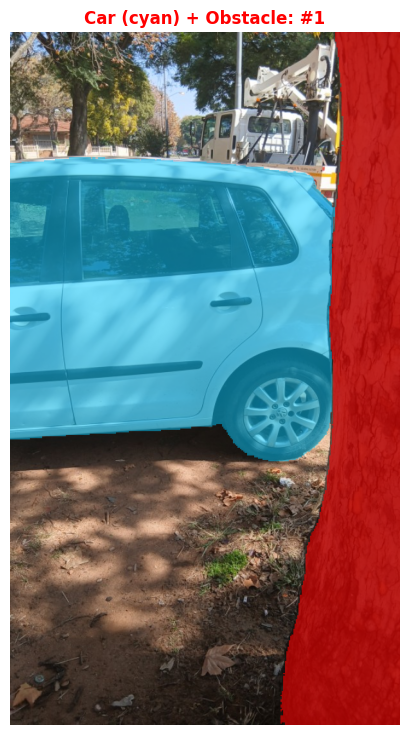

In [23]:
# Paint car (cyan) + the obstacles identified inline above (red)
CAR_COLOR = np.array([0, 200, 255])      # cyan
OBSTACLE_COLOR = np.array([255, 0, 0])   # red

result_overlay = image_rgb.copy()
oh, ow = image_rgb.shape[:2]

# Car mask first, obstacles drawn last so they win on overlap.
car_mask = cv2.resize(car["car_mask_bin"].astype(np.uint8), (ow, oh),
                      interpolation=cv2.INTER_NEAREST).astype(bool)
result_overlay[car_mask] = (result_overlay[car_mask] * 0.5 + CAR_COLOR * 0.5).astype(np.uint8)

for i in obstacle_idx:
    m = cv2.resize((sam_masks[i] > 0.5).astype(np.uint8), (ow, oh),
                   interpolation=cv2.INTER_NEAREST).astype(bool)
    result_overlay[m] = (result_overlay[m] * 0.4 + OBSTACLE_COLOR * 0.6).astype(np.uint8)

plt.figure(figsize=(12, 9))
plt.imshow(result_overlay)
title = ("Car (cyan) + Obstacle: " + ", ".join(f"#{i}" for i in obstacle_idx)) \
    if obstacle_exist else "Car (cyan) - No Obstacle"
plt.title(title, color="red" if obstacle_exist else "green", fontweight="bold")
plt.axis("off")
plt.show()